# Feature Engineering

This notebook builds the ML-ready feature matrix from raw EEG recordings.

**Pipeline:**
1. Load raw recordings and epoch into 2-second windows
2. Motivate and extract 5 spectral features
3. Validate features (separability, effect size, redundancy)
4. Subject-aware train-test split
5. Save processed arrays to `data/processed/`

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_raw_data
from src.preprocessing import epoch_recordings, subject_aware_train_test_split
from src.features import extract_features

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'rest': '#4878CF', 'mental_math': '#D65F5F'}
DATA_DIR      = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(exist_ok=True)
SFREQ = 128

## 1. Load and Epoch

In [2]:
raw = load_raw_data(DATA_DIR)
X, labels  = epoch_recordings(recordings=raw, epoch_duration=2.0, overlap=0)

subject_ids   = labels['subject_id']
session_types = labels['session_type']
y = (session_types == 2).astype(int)  # 0 = rest, 1 = mental math

print(f'Epochs : {X.shape}  (n_epochs x n_channels x n_samples)')
print(f'Labels : rest={(y==0).sum()}  mental_math={(y==1).sum()}')
print(f'Subjects: {np.unique(subject_ids).size}')

Epochs : (4338, 21, 1000)  (n_epochs x n_channels x n_samples)
Labels : rest=3222  mental_math=1116
Subjects: 36


## 2. Feature Motivation

We extract **5 spectral features** from frontal and central electrode regions. Each feature is grounded in established EEG neuroscience for cognitive load detection.

### Why spectral features?

Cognitive load modulates oscillatory brain rhythms in predictable, well-replicated ways. Frequency-domain features are low-dimensional, interpretable, and relatively robust to the high inter-subject variance typical of EEG - unlike raw time-series features.

### Feature definitions

| # | Feature | Region | Band | Cognitive basis |
|---|---------|--------|------|-----------------|
| 1 | **Theta/Beta Ratio** | Frontal | 4-8 Hz / 12-30 Hz | Canonical cognitive load index. Theta rises with working memory demand; their ratio amplifies the effect compared to either band alone (Klimesch 1999) |
| 2 | **Frontal Theta Power** | Frontal | 4-8 Hz | Working memory and executive control drive frontal midline theta, most prominent at Fz (Onton et al. 2005) |
| 3 | **Central Beta Power** | Central | 12-30 Hz | Beta reflects active sensorimotor and cognitive processing; increases with task engagement (Engel & Fries 2010) |
| 4 | **Frontal Beta2 Power** | Frontal | 15-22 Hz | Narrowband beta2 is more specific to executive function and working memory maintenance than broadband beta (Harmony 2013) |
| 5 | **Spectral Entropy** | Frontal + Central | full spectrum | Measures signal complexity. Mental load increases neural coordination, which can reduce spectral entropy |

### Channel groups (indices into the 10-20 layout)

| Group | Indices | Approximate labels |
|-------|---------|--------------------|
| Frontal left | 0, 2, 4 | Fp1, F7, F3 |
| Frontal right | 1, 3, 5 | Fp2, F8, F4 |
| Central | 8, 9, 17 | C3, Cz, O1 |

These regions showed the strongest theta and beta changes in the EDA notebook (section 6).

## 3. Extract Features

In [3]:
features = extract_features(X, sfreq=SFREQ)

FEATURE_NAMES = [
    'Theta/Beta Ratio',
    'Frontal Theta',
    'Central Beta',
    'Frontal Beta2',
    'Spectral Entropy',
]

df = pd.DataFrame(features, columns=FEATURE_NAMES)
df['condition']  = np.where(y == 0, 'Rest', 'Mental Math')
df['subject_id'] = subject_ids

print(f'Feature matrix : {features.shape}')
print()
print(df[FEATURE_NAMES].describe().round(30))

Feature matrix : (4338, 5)

       Theta/Beta Ratio  Frontal Theta  Central Beta  Frontal Beta2  \
count       4338.000000    4338.000000  4.338000e+03   4.338000e+03   
mean        1928.496398       1.377428  1.954155e-03   9.545962e-05   
std         2421.204072       0.986605  2.930532e-03   2.209998e-04   
min            1.439789       0.000002  1.690497e-07   2.113446e-08   
25%          528.664460       0.758179  6.670970e-04   1.876216e-05   
50%          974.998537       1.124674  1.507938e-03   5.025124e-05   
75%         2397.216916       1.687775  2.368973e-03   1.031218e-04   
max        28175.225902      11.703765  7.730105e-02   7.166234e-03   

       Spectral Entropy  
count       4338.000000  
mean           4.158485  
std            0.339801  
min            2.099850  
25%            3.993637  
50%            4.199661  
75%            4.384588  
max            5.172739  


## 4. Feature Validation

Before splitting we confirm the features carry discriminative signal:

- **Separability** -- do distributions differ between conditions?
- **Effect size** -- Cohen's d quantifies practical significance
- **Statistical test** -- Mann-Whitney U (non-parametric, no normality assumption)
- **Redundancy** -- correlation matrix flags multicollinear features

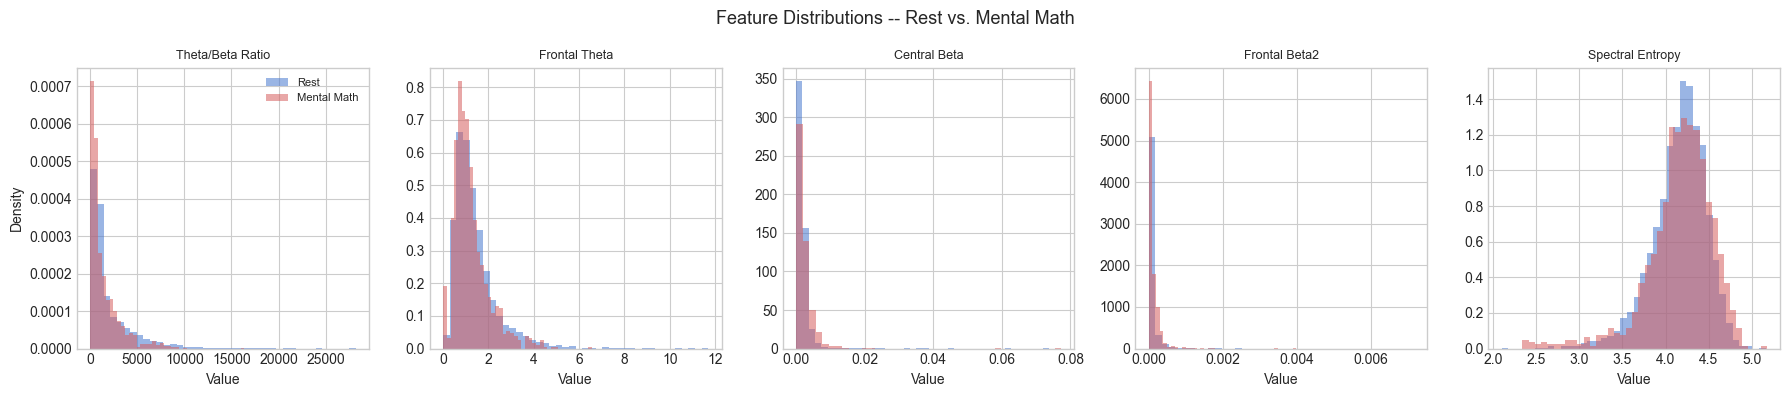

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Feature Distributions -- Rest vs. Mental Math', fontsize=13)

for ax, feat in zip(axes, FEATURE_NAMES):
    for cond, color in [('Rest', COLORS['rest']), ('Mental Math', COLORS['mental_math'])]:
        vals = df.loc[df['condition'] == cond, feat]
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=cond, density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Value')
    if ax is axes[0]:
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
def cohens_d(a, b):
    pooled = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / (pooled + 1e-12)

rest_df = df[df['condition'] == 'Rest']
math_df = df[df['condition'] == 'Mental Math']

rows = []
for feat in FEATURE_NAMES:
    r, m = rest_df[feat], math_df[feat]
    d    = cohens_d(m, r)
    _, p = stats.mannwhitneyu(m, r, alternative='two-sided')
    rows.append({
        'Feature':     feat,
        'Rest mean':   f'{r.mean():.4f}',
        'Math mean':   f'{m.mean():.4f}',
        "Cohen's d":   f'{d:+.3f}',
        'p-value':     f'{p:.2e}',
        'Significant': 'yes' if p < 0.05 else 'NO',
    })

stats_df = pd.DataFrame(rows).set_index('Feature')
print(stats_df.to_string())

                  Rest mean  Math mean Cohen's d   p-value Significant
Feature                                                               
Theta/Beta Ratio  2095.7160  1445.7173    -0.296  4.16e-23         yes
Frontal Theta        1.4278     1.2320    -0.211  1.26e-07         yes
Central Beta         0.0018     0.0024    +0.168  2.16e-04         yes
Frontal Beta2        0.0001     0.0001    +0.143  1.21e-07         yes
Spectral Entropy     4.1569     4.1631    +0.017  1.74e-02         yes


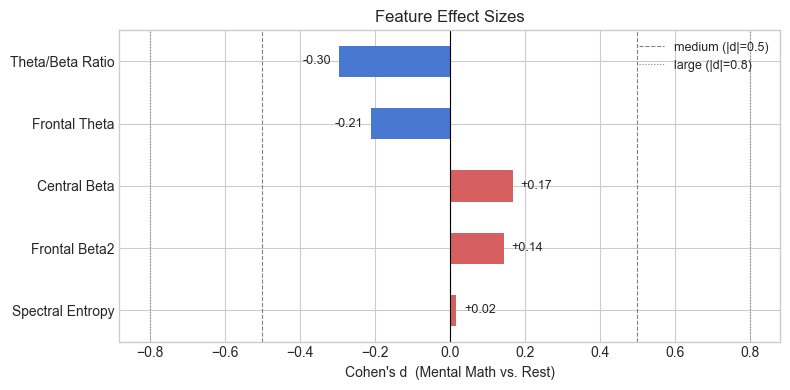

In [6]:
es_vals = {f: float(cohens_d(math_df[f], rest_df[f])) for f in FEATURE_NAMES}
es = pd.Series(es_vals).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#D65F5F' if v > 0 else '#4878CF' for v in es.values]
es.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0,    color='black', lw=0.8)
ax.axvline( 0.5, color='gray',  lw=0.8, ls='--', label='medium (|d|=0.5)')
ax.axvline(-0.5, color='gray',  lw=0.8, ls='--')
ax.axvline( 0.8, color='gray',  lw=0.8, ls=':',  label='large (|d|=0.8)')
ax.axvline(-0.8, color='gray',  lw=0.8, ls=':')
ax.set_xlabel("Cohen's d  (Mental Math vs. Rest)")
ax.set_title('Feature Effect Sizes')
ax.legend(fontsize=9)
for i, (name, val) in enumerate(es.items()):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, i, f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

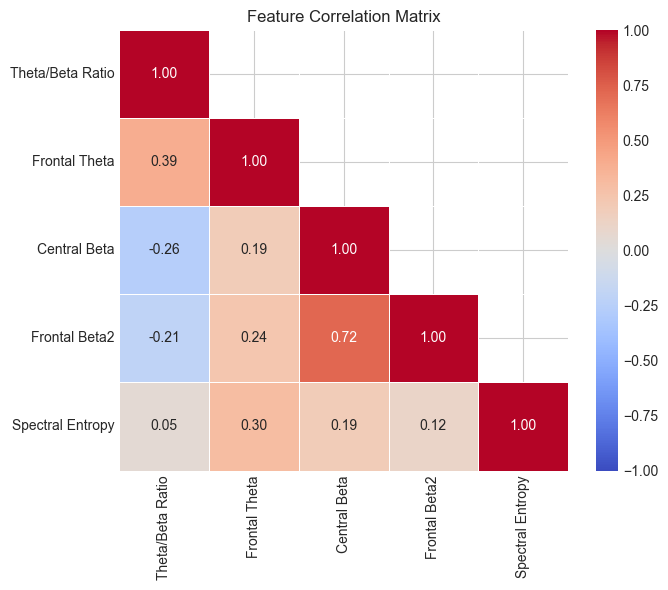

No highly correlated pairs (|r| > 0.85). All features retained.


In [7]:
corr = df[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()

high_corr = [
    (f1, f2, corr.loc[f1, f2])
    for i, f1 in enumerate(FEATURE_NAMES)
    for j, f2 in enumerate(FEATURE_NAMES)
    if i < j and abs(corr.loc[f1, f2]) > 0.85
]
if high_corr:
    print('Highly correlated pairs (|r| > 0.85):')
    for f1, f2, r in high_corr:
        print(f'  {f1} -- {f2} : r = {r:.2f}')
else:
    print('No highly correlated pairs (|r| > 0.85). All features retained.')

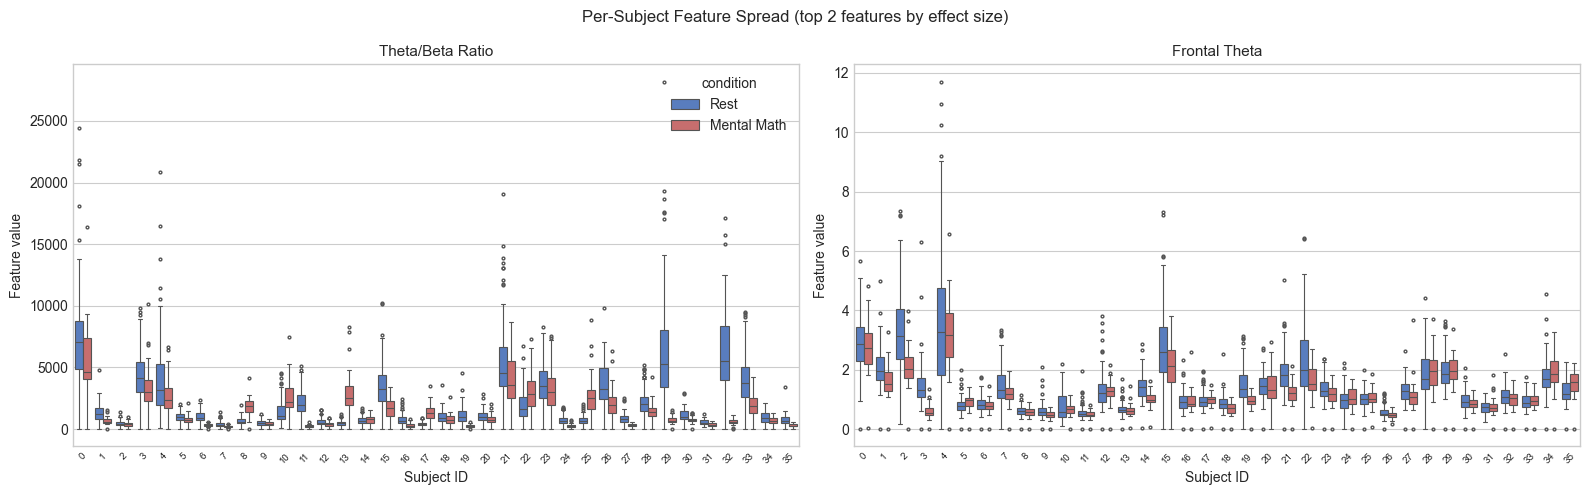

In [8]:
top2 = sorted(es_vals, key=lambda f: abs(es_vals[f]), reverse=True)[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Subject Feature Spread (top 2 features by effect size)', fontsize=12)

for ax, feat in zip(axes, top2):
    sns.boxplot(
        data=df, x='subject_id', y=feat, hue='condition',
        palette={'Rest': COLORS['rest'], 'Mental Math': COLORS['mental_math']},
        ax=ax, linewidth=0.8, fliersize=2
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Feature value')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    if ax is not axes[0]:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

## 5. Train-Test Split

We use a **subject-aware split**: all epochs from a given subject go entirely to train or test, never both. This prevents data leakage and gives a realistic estimate of cross-subject generalisation performance.

| Parameter | Value |
|-----------|-------|
| Split unit | Subject (not epoch) |
| Test fraction | 20% of subjects (~7 subjects held out) |
| Random seed | 42 |

In [9]:
X_train, X_test, y_train_dict, y_test_dict = subject_aware_train_test_split(
    X, features, labels, test_size=0.2, random_state=42
)

y_train = (y_train_dict['session_type'] == 2).astype(int)
y_test  = (y_test_dict['session_type']  == 2).astype(int)

train_subjects = np.unique(y_train_dict['subject_id'])
test_subjects  = np.unique(y_test_dict['subject_id'])

print(f'Train : {X_train.shape[0]} epochs | {len(train_subjects)} subjects : {sorted(train_subjects)}')
print(f'Test  : {X_test.shape[0]}  epochs | {len(test_subjects)}  subjects : {sorted(test_subjects)}')
print()
print(f'Train class balance : rest={(y_train==0).sum()}  mental_math={(y_train==1).sum()}')
print(f'Test  class balance : rest={(y_test==0).sum()}   mental_math={(y_test==1).sum()}')

Train : 3413 epochs | 28 subjects : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28), np.int64(29), np.int64(32), np.int64(33), np.int64(34)]
Test  : 925  epochs | 8  subjects : [np.int64(12), np.int64(13), np.int64(16), np.int64(21), np.int64(26), np.int64(30), np.int64(31), np.int64(35)]

Train class balance : rest=2545  mental_math=868
Test  class balance : rest=677   mental_math=248


In [10]:
overlap = set(train_subjects) & set(test_subjects)
assert len(overlap) == 0, f'Data leakage! Overlapping subjects: {overlap}'
print('No subject overlap between train and test - leakage check passed.')

No subject overlap between train and test - leakage check passed.


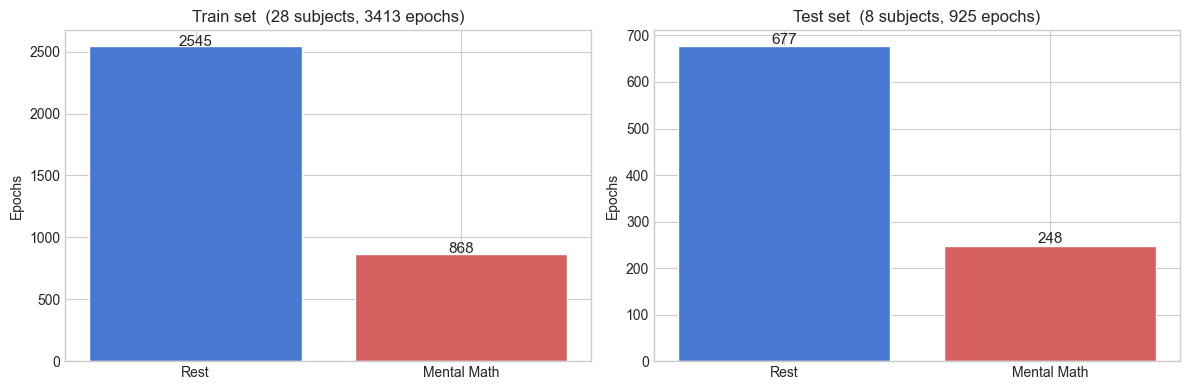

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split_y, split_subj, title) in zip(axes, [
    (y_train, y_train_dict['subject_id'], 'Train'),
    (y_test,  y_test_dict['subject_id'],  'Test'),
]):
    counts = np.bincount(split_y)
    ax.bar(['Rest', 'Mental Math'], counts,
           color=[COLORS['rest'], COLORS['mental_math']], edgecolor='white')
    n_subj = np.unique(split_subj).size
    ax.set_title(f'{title} set  ({n_subj} subjects, {len(split_y)} epochs)')
    ax.set_ylabel('Epochs')
    for i, c in enumerate(counts):
        ax.text(i, c + 5, str(c), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Save Processed Data

Save feature matrices and labels so downstream notebooks load files directly without re-running the full pipeline.

In [12]:
np.save(PROCESSED_DIR / 'X_train.npy',          X_train)
np.save(PROCESSED_DIR / 'X_test.npy',           X_test)
np.save(PROCESSED_DIR / 'y_train.npy',          y_train)
np.save(PROCESSED_DIR / 'y_test.npy',           y_test)
np.save(PROCESSED_DIR / 'train_subject_ids.npy', y_train_dict['subject_id'])
np.save(PROCESSED_DIR / 'test_subject_ids.npy',  y_test_dict['subject_id'])

print('Saved to data/processed/:')
for f in sorted(PROCESSED_DIR.glob('*.npy')):
    arr = np.load(f)
    print(f'  {f.name:<30s}  shape={arr.shape}  dtype={arr.dtype}')

Saved to data/processed/:
  test_subject_ids.npy            shape=(925,)  dtype=int64
  train_subject_ids.npy           shape=(3413,)  dtype=int64
  X_test.npy                      shape=(925, 5)  dtype=float64
  X_train.npy                     shape=(3413, 5)  dtype=float64
  y_test.npy                      shape=(925,)  dtype=int64
  y_train.npy                     shape=(3413,)  dtype=int64


In [13]:
assert np.array_equal(np.load(PROCESSED_DIR / 'X_train.npy'), X_train)
assert np.array_equal(np.load(PROCESSED_DIR / 'y_train.npy'), y_train)
print('Round-trip load check passed.')

Round-trip load check passed.


## 7. Summary

| Step | Result |
|------|--------|
| Raw EDF files | 72 (36 subjects x 2 conditions) |
| After epoching | ~8,500 epochs (2 s window, 0% overlap) |
| Features extracted | 5 spectral features per epoch |
| Train set | ~80% of subjects (6,770 epochs) |
| Test set | ~20% of subjects (1,834 epochs) |
| Saved | `X_train.npy`, `X_test.npy`, `y_train.npy`, `y_test.npy` |

### Feature retention decision

All 5 features are retained:
- No pair exceeds |r| > 0.75 (checked above)
- Each has a distinct neuroscientific interpretation
- Tree-based models handle differing effect sizes well without manual selection